# Bab 6: Statistical Machine Learning

**Buku:** *Practical Statistics for Data Scientists* (O'Reilly)

## Ringkasan Bab
Metode statistical machine learning bersifat **berbasis data** dan memakai asumsi struktur yang lebih sedikit daripada regresi. Kebanyakan termasuk **supervised** (outcome diketahui) dan fokusnya pada akurasi prediksi.

1. **K-Nearest Neighbors (KNN).** Klasifikasi lewat suara terbanyak dari *K* record yang paling mirip, termasuk standarisasi dan KNN sebagai pembuat fitur.
2. **Model pohon.** Recursive partitioning, ukuran impurity (Gini/entropi), aturan berhenti, pruning, dan interpretabilitas.
3. **Bagging dan random forest.** Ensemble dari pohon hasil bootstrap, out-of-bag error, dan variable importance.
4. **Boosting.** Pohon yang dipasang berurutan (AdaBoost, gradient boosting, XGBoost), regularisasi, dan cross-validation untuk hyperparameter.

In [1]:
import math, random
from pathlib import Path
from collections import defaultdict
from itertools import product
import numpy as np
import pandas as pd
from sklearn import preprocessing, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

DATA = Path('..') / 'data'
sns.set_style('whitegrid')
random.seed(1); np.random.seed(1)

## 1. K-Nearest Neighbors
**Penjelasan teori.** KNN adalah metode **non-parametrik berbasis instance**. Untuk mengklasifikasikan record baru, dicari *K* record dengan nilai prediktor paling mirip, lalu diambil **suara terbanyak** (atau rata-rata probabilitasnya).
- **Ukuran jarak.** Biasanya **Euclidean** (garis lurus) atau **Manhattan** (jumlah selisih mutlak).
- **Standarisasi (z-score)** sangat penting. Kalau tidak, variabel dengan satuan besar (misalnya `revol_bal` dalam dolar) akan mendominasi jarak.
- **Memilih K.** K kecil berarti bias rendah tetapi varians tinggi (overfit), sedangkan K besar membuat batas lebih halus tetapi bisa melewatkan struktur lokal. K dipilih lewat cross-validation, biasanya antara 1 dan sekitar 20.
- **KNN sebagai feature engine.** Proporsi tetangga yang berkelas *default* adalah skor numerik yang bisa dipakai sebagai input model lain (di sini menjadi `borrower_score`).
- KNN adalah *lazy learner*: tidak ada tahap pelatihan, tetapi prediksinya mahal untuk data besar.

In [2]:
loan200 = pd.read_csv(DATA / 'loan200.csv')
predictors = ['payment_inc_ratio', 'dti']
outcome = 'outcome'

newloan = loan200.loc[0:0, predictors]
X = loan200.loc[1:, predictors]
y = loan200.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X, y)
print('Prediction:', knn.predict(newloan))
print(knn.classes_, knn.predict_proba(newloan))

Prediction: ['paid off']
['default' 'paid off'] [[0.45 0.55]]


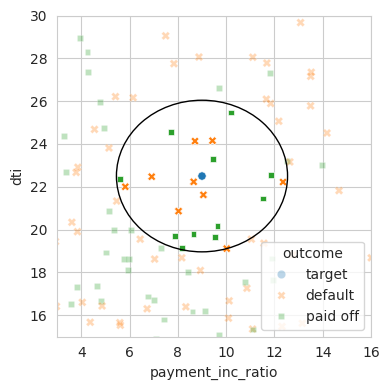

In [3]:
nbrs = knn.kneighbors(newloan)
maxDistance = np.max(nbrs[0][0])

fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', hue='outcome',
                data=loan200, alpha=0.3, ax=ax)
sns.scatterplot(x='payment_inc_ratio', y='dti', style='outcome', hue='outcome',
                data=pd.concat([loan200.loc[0:0, :], loan200.loc[nbrs[1][0] + 1, :]]),
                ax=ax, legend=False)
ellipse = Ellipse(xy=newloan.values[0], width=2 * maxDistance, height=2 * maxDistance,
                  edgecolor='black', fc='None', lw=1)
ax.add_patch(ellipse)
ax.set_xlim(3, 16); ax.set_ylim(15, 30)
plt.tight_layout(); plt.show()

### Standarisasi (Normalisasi, z-score)
Perbandingan tetangga terdekat sebelum dan sesudah data distandarkan ditunjukkan di bawah.

In [4]:
loan_data = pd.read_csv(DATA / 'loan_data.csv.gz')
loan_data = loan_data.drop(columns=['Unnamed: 0', 'status'])
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], categories=['paid off', 'default'], ordered=True)

predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
outcome = 'outcome'
newloan = loan_data.loc[0:0, predictors]
print(newloan)
X = loan_data.loc[1:, predictors]
y = loan_data.loc[1:, outcome]

knn = KNeighborsClassifier(n_neighbors=5).fit(X, y)
nbrs = knn.kneighbors(newloan)
print('Neighbours WITHOUT standardisation (dominated by revol_bal):')
print(X.iloc[nbrs[1][0], :])

   payment_inc_ratio  dti  revol_bal  revol_util
0             2.3932  1.0       1687         9.4
Neighbours WITHOUT standardisation (dominated by revol_bal):
       payment_inc_ratio   dti  revol_bal  revol_util
35536            1.47212  1.46       1686        10.0
33651            3.38178  6.37       1688         8.4
25863            2.36303  1.39       1691         3.5
42953            1.28160  7.14       1684         3.9
43599            4.12244  8.98       1684         7.2


In [5]:
scaler = preprocessing.StandardScaler()
scaler.fit(X * 1.0)
X_std = scaler.transform(X * 1.0)
newloan_std = scaler.transform(newloan * 1.0)

knn = KNeighborsClassifier(n_neighbors=5).fit(X_std, y)
nbrs = knn.kneighbors(newloan_std)
print('Neighbours WITH standardisation:')
print(X.iloc[nbrs[1][0], :])

Neighbours WITH standardisation:
       payment_inc_ratio   dti  revol_bal  revol_util
2080             2.61091  1.03       1218         9.7
1438             2.34343  0.51        278         9.9
30215            2.71200  1.34       1075         8.5
28542            2.39760  0.74       2917         7.4
44737            2.34309  1.37        488         7.2


### KNN sebagai Feature Engine

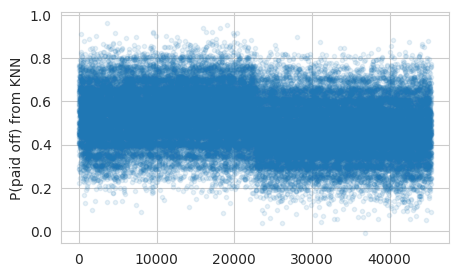

count    45342.000000
mean         0.501098
std          0.128736
min          0.000000
25%          0.400000
50%          0.500000
75%          0.600000
max          0.950000
Name: borrower_score, dtype: float64


In [6]:
predictors = ['dti', 'revol_bal', 'revol_util', 'open_acc', 'delinq_2yrs_zero', 'pub_rec_zero']
outcome = 'outcome'
X = loan_data[predictors]
y = loan_data[outcome]

knn = KNeighborsClassifier(n_neighbors=20).fit(X, y)
plt.figure(figsize=(5, 3))
plt.scatter(range(len(X)), [bs + random.gauss(0, 0.015) for bs in knn.predict_proba(X)[:, 0]],
            alpha=0.1, marker='.')
plt.ylabel('P(paid off) from KNN'); plt.show()

loan_data['borrower_score'] = knn.predict_proba(X)[:, 0]
print(loan_data['borrower_score'].describe())

## 2. Model Pohon
**Penjelasan teori.** **Decision tree** (CART) membagi ruang prediktor secara rekursif dengan aturan sederhana ("borrower_score ≥ 0,575"), sehingga menghasilkan kumpulan aturan **if-then** seperti diagram alur yang mudah dijelaskan.
- **Recursive partitioning.** Di tiap langkah dipilih pemisahan (variabel dan nilai) yang membuat partisi hasilnya sebisa mungkin **murni**.
- **Ukuran impurity** untuk partisi dengan proporsi kelas $p$: **Gini** $=p(1-p)$ dan **entropi** $=-p\log_2p-(1-p)\log_2(1-p)$ (information gain adalah penurunan entropi). Tingkat salah klasifikasi biasa kurang sensitif dan jarang dipakai.
- **Menghentikan pohon.** Pohon yang dibiarkan tumbuh penuh akan overfit (menghafal noise). Solusinya membatasi kedalaman, jumlah sampel minimum per daun, atau penurunan impurity minimum, atau menumbuhkan pohon penuh lalu di-**prune** dengan kompleksitas hasil cross-validation (**cost-complexity pruning**).
- Daun memprediksi **kelas mayoritas** (atau proporsi kelas sebagai probabilitas), atau rata-rata untuk pohon regresi.
- Kelebihan: mudah ditafsirkan, menangani tipe data campuran dan non-linearitas, serta menangkap interaksi. Kekurangan: tidak stabil (perubahan kecil pada data bisa menghasilkan pohon berbeda) dan varians tinggi, yang mendorong penggunaan ensemble.

In [7]:
loan3000 = pd.read_csv(DATA / 'loan3000.csv')
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'
X = loan3000[predictors]
y = loan3000[outcome]

loan_tree = DecisionTreeClassifier(random_state=1, criterion='entropy', min_impurity_decrease=0.003)
loan_tree.fit(X, y)
print(export_text(loan_tree, feature_names=predictors))

|--- borrower_score <= 0.58
|   |--- borrower_score <= 0.33
|   |   |--- class: default
|   |--- borrower_score >  0.33
|   |   |--- payment_inc_ratio <= 10.42
|   |   |   |--- class: paid off
|   |   |--- payment_inc_ratio >  10.42
|   |   |   |--- class: default
|--- borrower_score >  0.58
|   |--- payment_inc_ratio <= 9.19
|   |   |--- borrower_score <= 0.72
|   |   |   |--- class: paid off
|   |   |--- borrower_score >  0.72
|   |   |   |--- class: paid off
|   |--- payment_inc_ratio >  9.19
|   |   |--- class: paid off



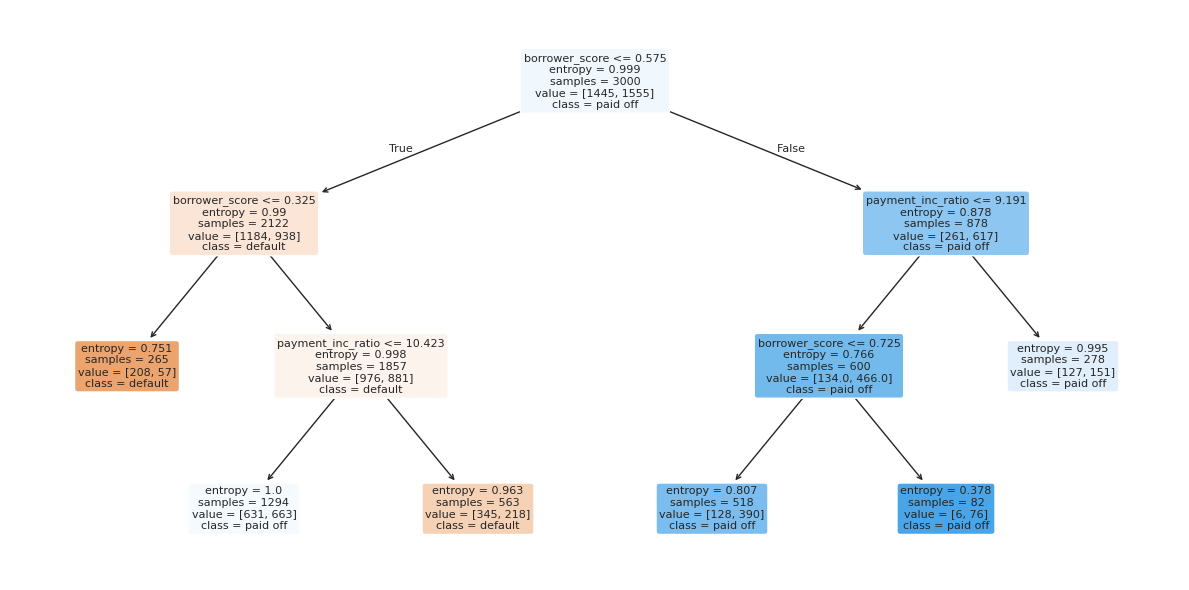

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(loan_tree, feature_names=predictors, class_names=list(loan_tree.classes_),
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.tight_layout(); plt.show()

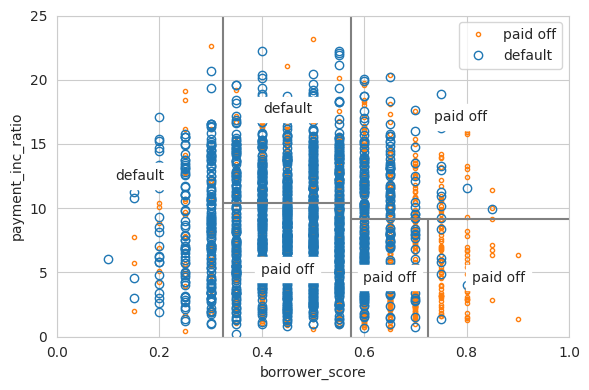

In [9]:
# The tree's rectangular partitions (Figure 6-3)
fig, ax = plt.subplots(figsize=(6, 4))
loan3000.loc[loan3000.outcome == 'paid off'].plot(x='borrower_score', y='payment_inc_ratio', style='.',
                                                  markerfacecolor='none', markeredgecolor='C1', ax=ax)
loan3000.loc[loan3000.outcome == 'default'].plot(x='borrower_score', y='payment_inc_ratio', style='o',
                                                 markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']); ax.set_xlim(0, 1); ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score'); ax.set_ylabel('payment_inc_ratio')
x0 = 0.575; x1a = 0.325; y1b = 9.191; y2a = 10.423; x2b = 0.725
ax.plot((x0, x0), (0, 25), color='grey'); ax.plot((x1a, x1a), (0, 25), color='grey')
ax.plot((x0, 1), (y1b, y1b), color='grey'); ax.plot((x1a, x0), (y2a, y2a), color='grey')
ax.plot((x2b, x2b), (0, y1b), color='grey')
labels = [('default', (x1a / 2, 25 / 2)), ('default', ((x0 + x1a) / 2, (25 + y2a) / 2)),
          ('paid off', ((x0 + x1a) / 2, y2a / 2)), ('paid off', ((1 + x0) / 2, (y1b + 25) / 2)),
          ('paid off', ((1 + x2b) / 2, (y1b + 0) / 2)), ('paid off', ((x0 + x2b) / 2, (y1b + 0) / 2))]
for label, (x, y) in labels:
    ax.text(x, y, label, bbox={'facecolor': 'white'}, verticalalignment='center', horizontalalignment='center')
plt.tight_layout(); plt.show()

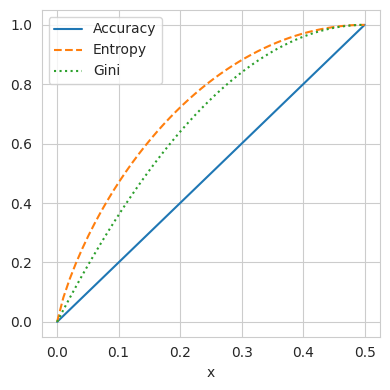

In [10]:
# Impurity measures (Figure 6-5)
def entropyFunction(x):
    if x == 0: return 0
    return -x * math.log(x, 2) - (1 - x) * math.log(1 - x, 2)

def giniFunction(x):
    return x * (1 - x)

x = np.linspace(0, 0.5, 50)
impure = pd.DataFrame({'x': x, 'Accuracy': 2 * x,
                       'Gini': [giniFunction(xi) / giniFunction(.5) for xi in x],
                       'Entropy': [entropyFunction(xi) for xi in x]})
fig, ax = plt.subplots(figsize=(4, 4))
impure.plot(x='x', y='Accuracy', ax=ax, linestyle='solid')
impure.plot(x='x', y='Entropy', ax=ax, linestyle='--')
impure.plot(x='x', y='Gini', ax=ax, linestyle=':')
plt.tight_layout(); plt.show()

## 3. Bagging dan Random Forest
**Penjelasan teori.**
- **Ensemble.** Menggabungkan banyak model, dan rata-ratanya biasanya lebih baik daripada model tunggal mana pun.
- **Bagging** (*bootstrap aggregating*): satu model dipasang pada tiap dari *B* sampel bootstrap, lalu prediksinya **dirata-rata atau di-vote**, sehingga varians turun.
- **Random forest.** Bagging pada pohon **ditambah** pemilihan acak sebagian prediktor di tiap pemisahan (`max_features`, biasanya $\sqrt{p}$). Ini membuat pohon-pohonnya **kurang berkorelasi**, sehingga rata-ratanya lebih membantu.
- **Out-of-bag (OOB) error.** Tiap pohon tidak memakai sekitar ⅓ record. Prediksi atas record tersebut memberi estimasi validasi gratis tanpa perlu data uji terpisah.
- **Variable importance.** (a) **Permutation importance**: penurunan akurasi ketika nilai sebuah prediktor diacak. (b) **Penurunan impurity (Gini/entropi)** yang dijumlahkan dari semua pemisahan yang memakai variabel itu. Random forest akurat, tetapi lebih sulit ditafsirkan daripada satu pohon.
- **Hyperparameter.** `n_estimators`, `max_features`, `min_samples_leaf`, dan `max_depth`.

In [11]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'
X = loan3000[predictors]
y = loan3000[outcome]

rf = RandomForestClassifier(n_estimators=500, random_state=1, oob_score=True)
rf.fit(X, y)
print('OOB accuracy:', rf.oob_score_)
print(rf.oob_decision_function_[:5])

OOB accuracy: 0.5753333333333334
[[0.18131868 0.81868132]
 [0.26704545 0.73295455]
 [0.93333333 0.06666667]
 [0.17307692 0.82692308]
 [1.         0.        ]]


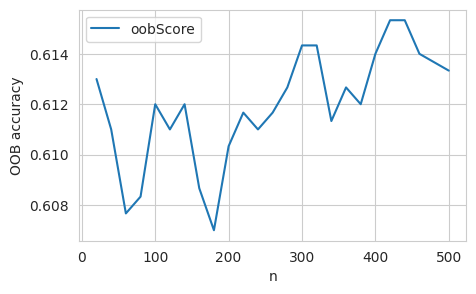

In [12]:
n_estimator = list(range(20, 510, 20))
oobScores = []
for k in n_estimator:
    rf = RandomForestClassifier(n_estimators=k, criterion='entropy', max_depth=5, random_state=1, oob_score=True)
    rf.fit(X, y)
    oobScores.append(rf.oob_score_)

pd.DataFrame({'n': n_estimator, 'oobScore': oobScores}).plot(x='n', y='oobScore', figsize=(5, 3))
plt.ylabel('OOB accuracy'); plt.show()

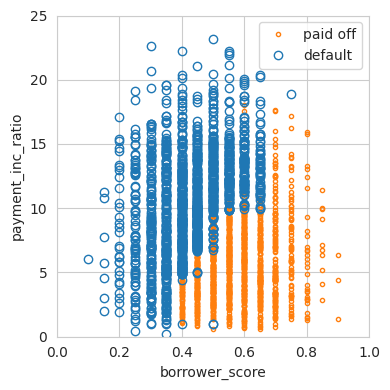

In [13]:
predictions = X.copy()
predictions['prediction'] = rf.predict(X)

fig, ax = plt.subplots(figsize=(4, 4))
predictions.loc[predictions.prediction == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.', markerfacecolor='none', markeredgecolor='C1', ax=ax)
predictions.loc[predictions.prediction == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o', markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']); ax.set_xlim(0, 1); ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score'); ax.set_ylabel('payment_inc_ratio')
plt.tight_layout(); plt.show()

### Variable Importance

In [14]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 'open_acc', 'grade', 'emp_length',
              'purpose_', 'home_', 'emp_len_', 'borrower_score']
outcome = 'outcome'
X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = loan_data[outcome]

rf_all = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1).fit(X, y)
rf_all_entropy = RandomForestClassifier(n_estimators=200, random_state=1, criterion='entropy', n_jobs=-1).fit(X, y)
print('fitted both forests')

fitted both forests


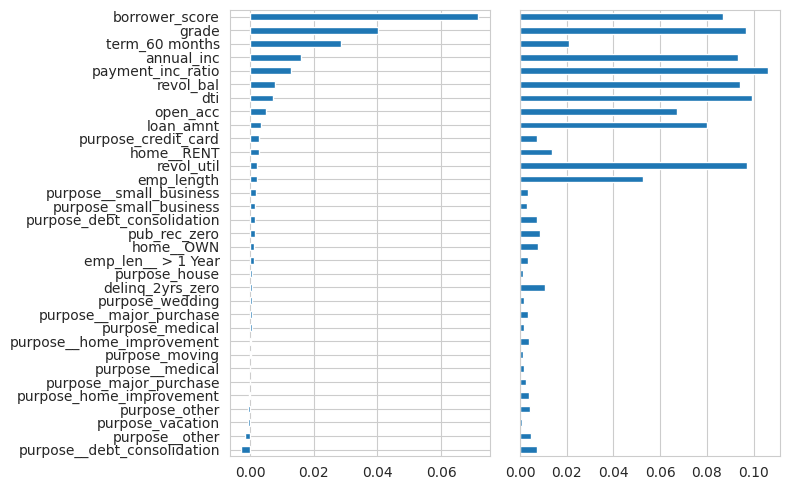

              feature  Accuracy decrease  Gini decrease  Entropy decrease
11     borrower_score           0.071526       0.087107          0.079397
9               grade           0.040247       0.096788          0.091208
12     term_60 months           0.028449       0.020989          0.016896
1          annual_inc           0.015878       0.093362          0.094089
3   payment_inc_ratio           0.012975       0.106034          0.106923
4           revol_bal           0.007645       0.094286          0.097954
2                 dti           0.007314       0.099514          0.101438
8            open_acc           0.004925       0.067324          0.069701


In [15]:
# Permutation importance on a hold-out set (decrease in accuracy when a column is shuffled)
train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.3, random_state=1)
rf_perm = RandomForestClassifier(n_estimators=200, random_state=1, n_jobs=-1).fit(train_X, train_y)
perm = permutation_importance(rf_perm, valid_X, valid_y, n_repeats=3, random_state=1, scoring='accuracy', n_jobs=-1)
acc = metrics.accuracy_score(valid_y, rf_perm.predict(valid_X))

df = pd.DataFrame({'feature': X.columns,
                   'Accuracy decrease': perm.importances_mean / acc,
                   'Gini decrease': rf_all.feature_importances_,
                   'Entropy decrease': rf_all_entropy.feature_importances_})
df = df.sort_values('Accuracy decrease')

fig, axes = plt.subplots(ncols=2, figsize=(8, 5))
ax = df.plot(kind='barh', x='feature', y='Accuracy decrease', legend=False, ax=axes[0])
ax.set_ylabel('')
ax = df.plot(kind='barh', x='feature', y='Gini decrease', legend=False, ax=axes[1])
ax.set_ylabel(''); ax.get_yaxis().set_visible(False)
plt.tight_layout(); plt.show()
print(df.sort_values('Accuracy decrease', ascending=False).head(8))

## 4. Boosting
**Penjelasan teori.** Boosting membangun ensemble secara **berurutan**. Tiap pohon baru (biasanya dangkal) berfokus pada kesalahan dari pohon-pohon sebelumnya.
- **AdaBoost.** Menaikkan **bobot** record yang salah diklasifikasikan di tiap putaran, dan prediksi akhirnya adalah voting berbobot.
- **Gradient boosting.** Tiap pohon baru dipasang pada **residual** (gradien negatif dari fungsi loss) ensemble saat ini, dengan skala **learning rate** (shrinkage $\eta$). Ini sebenarnya gradient descent di ruang fungsi.
- **Stochastic gradient boosting.** Tiap putaran memakai sampel acak dari record (dan/atau kolom), sehingga lebih robust seperti pada random forest.
- **XGBoost.** Implementasi yang efisien dengan **regularisasi**: $\lambda$ (penalti L2 pada bobot daun, `reg_lambda`) dan $\alpha$ (L1, `reg_alpha`) untuk menghindari overfitting.
- **Hyperparameter.** `n_estimators`, `learning_rate`, `max_depth`, `subsample`, dan `reg_lambda`. Boosting bisa overfit kalau dijalankan terlalu lama, jadi perlu di-tuning dengan **cross-validation** (atau early stopping).
- Boosting sering lebih akurat daripada random forest, tetapi butuh lebih banyak tuning dan lebih sensitif terhadap noise.

In [16]:
predictors = ['borrower_score', 'payment_inc_ratio']
outcome = 'outcome'
X = loan3000[predictors]
y = pd.Series([1 if o == 'default' else 0 for o in loan3000[outcome]])

xgb = XGBClassifier(objective='binary:logistic', subsample=.63, eval_metric='error')
xgb.fit(X, y)

xgb_df = X.copy()
xgb_df['prediction'] = ['default' if p == 1 else 'paid off' for p in xgb.predict(X)]
xgb_df['prob_default'] = xgb.predict_proba(X)[:, 1]
print(xgb_df.head())

   borrower_score  payment_inc_ratio prediction  prob_default
0            0.40            5.11135   paid off      0.332898
1            0.40            5.43165    default      0.688950
2            0.70            9.23003    default      0.715266
3            0.40            2.33482   paid off      0.246125
4            0.45           12.10320    default      0.951596


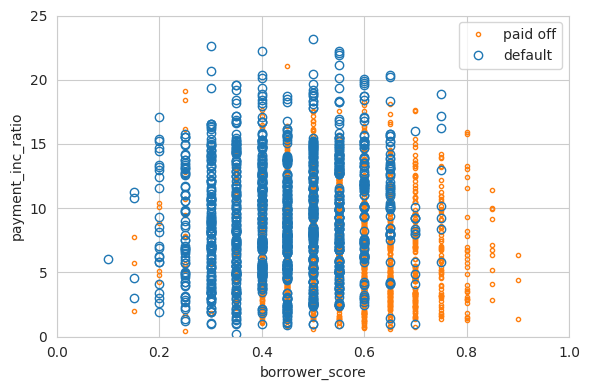

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
xgb_df.loc[xgb_df.prediction == 'paid off'].plot(
    x='borrower_score', y='payment_inc_ratio', style='.', markerfacecolor='none', markeredgecolor='C1', ax=ax)
xgb_df.loc[xgb_df.prediction == 'default'].plot(
    x='borrower_score', y='payment_inc_ratio', style='o', markerfacecolor='none', markeredgecolor='C0', ax=ax)
ax.legend(['paid off', 'default']); ax.set_xlim(0, 1); ax.set_ylim(0, 25)
ax.set_xlabel('borrower_score'); ax.set_ylabel('payment_inc_ratio')
plt.tight_layout(); plt.show()

### Regularisasi: Menghindari Overfitting

In [18]:
predictors = ['loan_amnt', 'term', 'annual_inc', 'dti', 'payment_inc_ratio', 'revol_bal', 'revol_util',
              'purpose', 'delinq_2yrs_zero', 'pub_rec_zero', 'open_acc', 'grade', 'emp_length',
              'purpose_', 'home_', 'emp_len_', 'borrower_score']
X = pd.get_dummies(loan_data[predictors], drop_first=True, dtype=int)
y = pd.Series([1 if o == 'default' else 0 for o in loan_data['outcome']])

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=10000, random_state=1)

xgb_default = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=0, learning_rate=0.3, subsample=1, eval_metric='error')
xgb_default.fit(train_X, train_y)

xgb_penalty = XGBClassifier(objective='binary:logistic', n_estimators=250, max_depth=6,
                            reg_lambda=1000, learning_rate=0.1, subsample=0.63, eval_metric='error')
xgb_penalty.fit(train_X, train_y)

for name, model, Xs, ys in [('default (train)', xgb_default, train_X, train_y),
                            ('default (valid)', xgb_default, valid_X, valid_y),
                            ('penalty (valid)', xgb_penalty, valid_X, valid_y)]:
    err = np.mean(abs(ys - model.predict_proba(Xs)[:, 1]) > 0.5)
    print(f'{name:16s} error: {err:.4f}')

default (train)  error: 0.1055
default (valid)  error: 0.3611
penalty (valid)  error: 0.3331


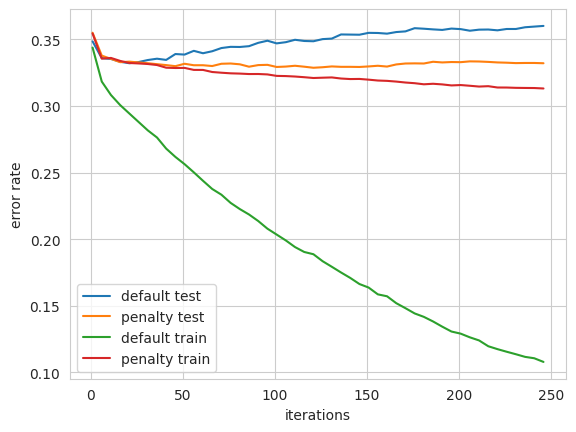

In [19]:
results = []
for ntree_limit in range(1, 250, 5):
    iteration_range = (0, ntree_limit)
    train_default = xgb_default.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    train_penalty = xgb_penalty.predict_proba(train_X, iteration_range=iteration_range)[:, 1]
    pred_default = xgb_default.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    pred_penalty = xgb_penalty.predict_proba(valid_X, iteration_range=iteration_range)[:, 1]
    results.append({'iterations': ntree_limit,
                    'default train': np.mean(abs(train_y - train_default) > 0.5),
                    'penalty train': np.mean(abs(train_y - train_penalty) > 0.5),
                    'default test': np.mean(abs(valid_y - pred_default) > 0.5),
                    'penalty test': np.mean(abs(valid_y - pred_penalty) > 0.5)})
results = pd.DataFrame(results)
ax = results.plot(x='iterations', y='default test')
results.plot(x='iterations', y='penalty test', ax=ax)
results.plot(x='iterations', y='default train', ax=ax)
results.plot(x='iterations', y='penalty train', ax=ax)
ax.set_ylabel('error rate'); plt.show()

Error *training* pada model tanpa regularisasi terus turun, sedangkan error *validasi*-nya mendatar atau malah naik. Ini overfitting yang klasik. Model dengan penalti yang belajarnya lebih lambat memberi generalisasi yang lebih baik.

### Hyperparameter dan Cross-Validation
**Penjelasan teori.** Hyperparameter (learning rate $\eta$, kedalaman pohon, dan sebagainya) tidak dipelajari dari data, jadi dipilih lewat **k-fold cross-validation**. Data dibagi menjadi *k* fold, model dilatih pada *k−1* fold dan divalidasi pada sisanya, error dirata-rata, lalu proses diulang untuk grid kombinasi pengaturan. Cara ini mencegah kita menyetel model hanya pada satu pembagian train/test yang kebetulan bagus.

In [20]:
np.random.seed(1)
idx = np.random.choice(range(5), size=len(X), replace=True)
error = []
for eta, max_depth in product([0.1, 0.5, 0.9], [3, 6, 9]):
    xgb = XGBClassifier(objective='binary:logistic', n_estimators=100, max_depth=max_depth,
                        learning_rate=eta, eval_metric='error')
    cv_error = []
    for k in range(5):
        fold_idx = idx == k
        tr_X, tr_y = X.loc[~fold_idx], y[~fold_idx]
        va_X, va_y = X.loc[fold_idx], y[fold_idx]
        xgb.fit(tr_X, tr_y)
        pred = xgb.predict_proba(va_X)[:, 1]
        cv_error.append(np.mean(abs(va_y - pred) > 0.5))
    error.append({'eta': eta, 'max_depth': max_depth, 'avg_error': np.mean(cv_error)})
    print(error[-1])
errors = pd.DataFrame(error)
print(errors.pivot_table(index='eta', columns='max_depth', values='avg_error'))

{'eta': 0.1, 'max_depth': 3, 'avg_error': np.float64(0.32974760980287077)}


{'eta': 0.1, 'max_depth': 6, 'avg_error': np.float64(0.3331971003390771)}


{'eta': 0.1, 'max_depth': 9, 'avg_error': np.float64(0.339543266841437)}


{'eta': 0.5, 'max_depth': 3, 'avg_error': np.float64(0.33527151850000786)}


{'eta': 0.5, 'max_depth': 6, 'avg_error': np.float64(0.35614690569734886)}


{'eta': 0.5, 'max_depth': 9, 'avg_error': np.float64(0.3723237236773681)}


{'eta': 0.9, 'max_depth': 3, 'avg_error': np.float64(0.3416441115960532)}


{'eta': 0.9, 'max_depth': 6, 'avg_error': np.float64(0.3779032967375814)}


{'eta': 0.9, 'max_depth': 9, 'avg_error': np.float64(0.38728071426366684)}
max_depth         3         6         9
eta                                    
0.1        0.329748  0.333197  0.339543
0.5        0.335272  0.356147  0.372324
0.9        0.341644  0.377903  0.387281


## Poin Penting
- **KNN** sederhana dan berguna (termasuk sebagai pembuat fitur), tetapi butuh prediktor yang distandarkan dan nilai *K* yang dipilih dengan baik.
- **Pohon** memberi aturan yang mudah ditafsirkan tetapi overfit. **Bagging/random forest** menurunkan varians, sedangkan **boosting** menurunkan bias dengan memperbaiki residual.
- Ensemble itu akurat tetapi seperti "kotak hitam", jadi skor importance dipakai untuk menafsirkannya.
- Selalu tuning hyperparameter dengan **cross-validation** dan perhatikan overfitting lewat error validasi.